# 1. Import libraies


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier

# Metrics
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

import warnings
warnings.filterwarnings('ignore')

# 2. Loading & Cleaning Data


In [8]:
df = pd.read_csv("D:\Telecom Customer Churn Project\dataset\Telco-Customer-Churn.csv")


df.drop_duplicates(inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

for col in df.select_dtypes(include='object').columns:
    if col != 'customerID':
        df[col] = df[col].str.strip().str.capitalize()

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,Dsl,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,Dsl,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,Dsl,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,Dsl,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3 (EDA - Exploratory Data Analysis)

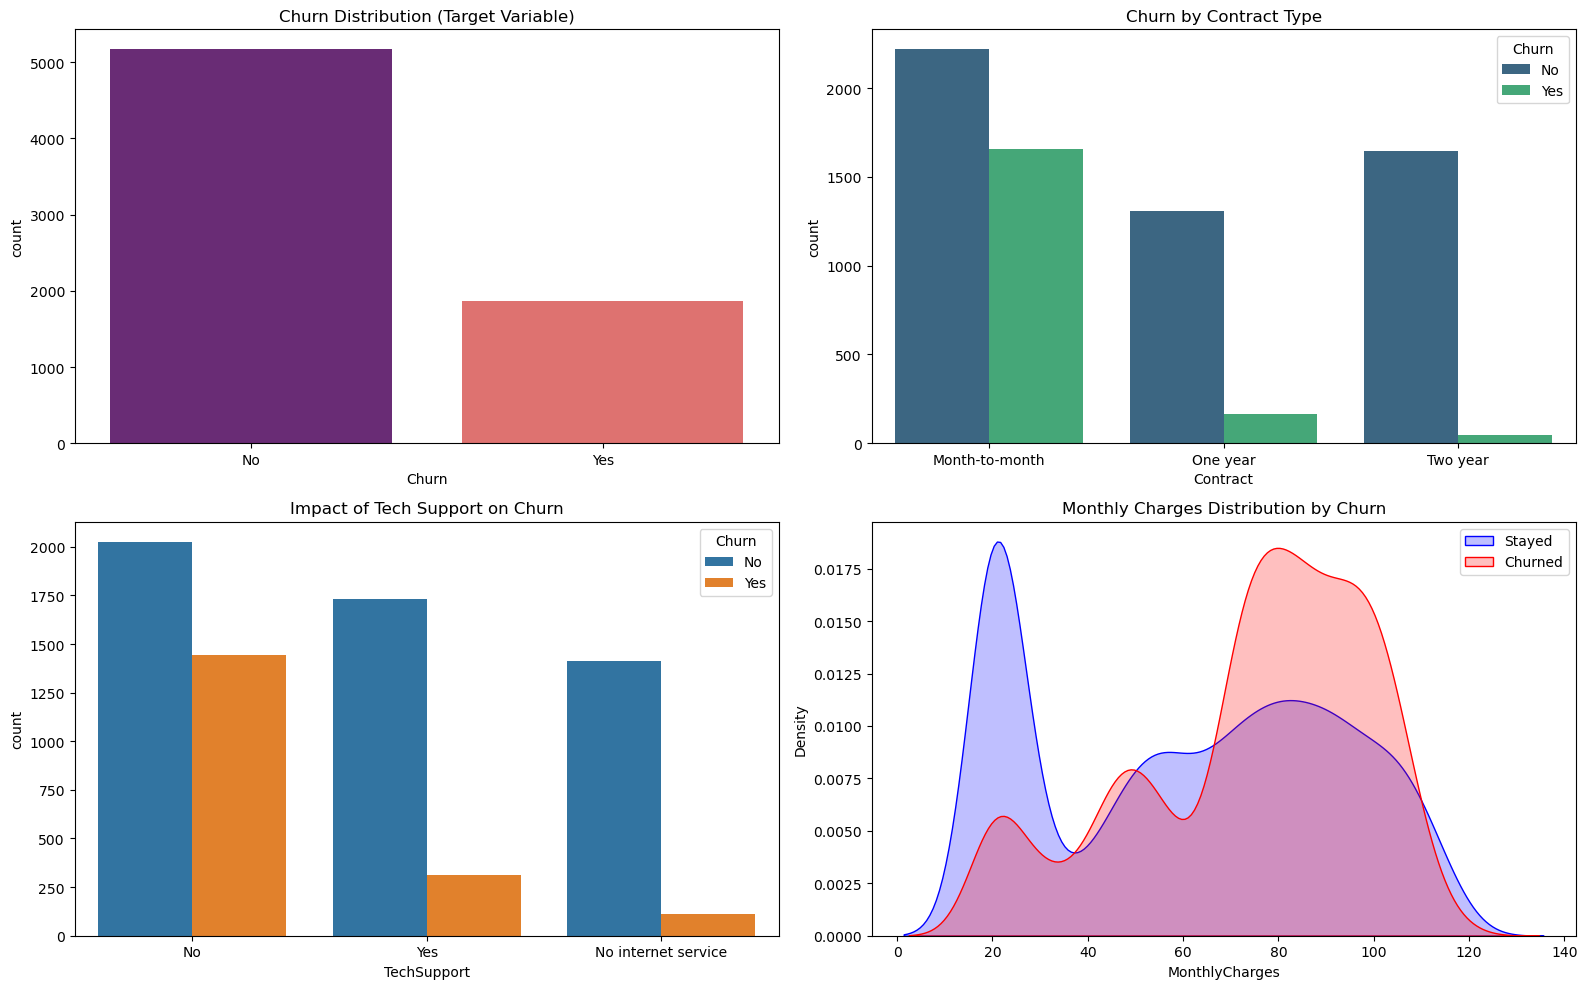

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# رسمة 1: الهدف
sns.countplot(x='Churn', data=df, palette='magma', ax=axes[0, 0])
axes[0, 0].set_title('Churn Distribution (Target Variable)')

# رسمة 2: نوع العقد
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Churn by Contract Type')

# رسمة 3: الدعم الفني
sns.countplot(x='TechSupport', hue='Churn', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Impact of Tech Support on Churn')

# رسمة 4: الفاتورة الشهرية
sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'], label='Stayed', fill=True, color='blue', ax=axes[1, 1])
sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], label='Churned', fill=True, color='red', ax=axes[1, 1])
axes[1, 1].set_title('Monthly Charges Distribution by Churn')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 4. Data Preprocessing

In [10]:
df = df.drop('customerID', axis=1)
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy='median')
cols = X_train.columns
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=cols)
X_test = pd.DataFrame(imputer.transform(X_test), columns=cols)

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


# 5. Model Training

In [11]:
base_models = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
]

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)

stack_model.fit(X_train, y_train)
y_pred = stack_model.predict(X_test)
y_prob = stack_model.predict_proba(X_test)[:, 1]

# Results
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
print("Model Results:")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Model Results:
Accuracy : 0.8176
ROC-AUC  : 0.8649
